<a href="https://colab.research.google.com/github/harsha0062/ml_learning/blob/main/percentile.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/ml -working/colab/Outliers Detection and removal techniques/Percentile /weight-height.csv')

In [3]:
df.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


In [4]:
df.shape

(10000, 3)

In [5]:
df['Height'].describe()

,Height
count,10000.000000
mean,66.367560
std,3.847528
min,54.263133
25%,63.505620
50%,66.318070
75%,69.174262
max,78.998742


<Axes: xlabel='Height', ylabel='Count'>

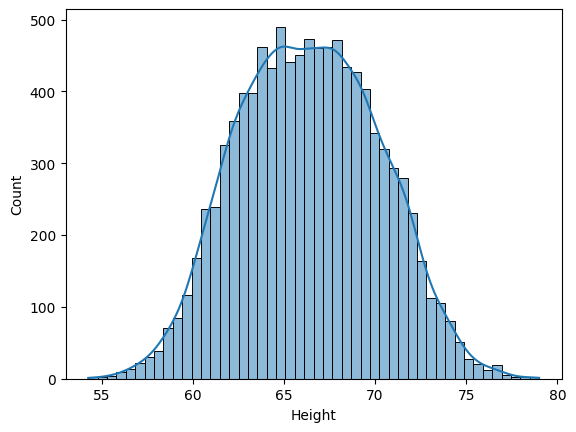

In [8]:
import seaborn as sns
sns.histplot(x=df['Height'],kde=True)

<Axes: xlabel='Height'>

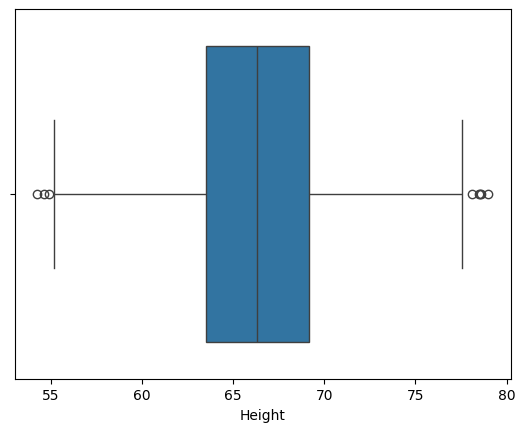

In [10]:
sns.boxplot(x=df['Height'])

In [13]:
upper_limit=df['Height'].quantile(0.99)
upper_limit=float(upper_limit)
upper_limit

74.7857900583366

In [14]:
lower_limit=df['Height'].quantile(0.01)
lower_limit=float(lower_limit)
lower_limit

58.13441158671655

In [16]:
new_df=df[(df['Height']<=74.78) & (df['Height']>=58.13)]


In [17]:
new_df['Height'].describe()

,Height
count,9799.000000
mean,66.363507
std,3.644267
min,58.134496
25%,63.577147
50%,66.317899
75%,69.119859
max,74.767447


In [18]:
df['Height'].describe()

,Height
count,10000.000000
mean,66.367560
std,3.847528
min,54.263133
25%,63.505620
50%,66.318070
75%,69.174262
max,78.998742


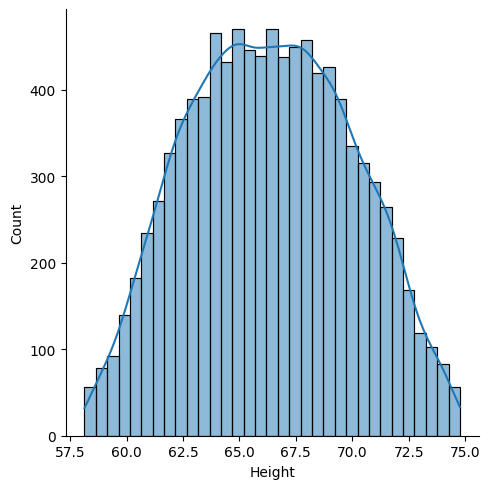

In [21]:
sns.displot(new_df['Height'],kde=True)

<Axes: xlabel='Height'>

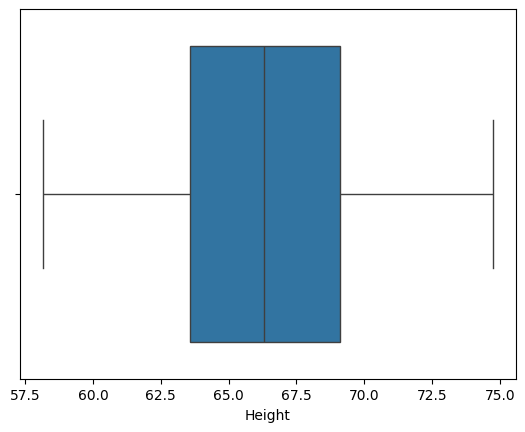

In [23]:
sns.boxplot(x=new_df['Height'])

In [26]:
# capping -> winsorization
df['Height']=np.where(df['Height']>=upper_limit,
                      upper_limit,
                      np.where(df['Height']<=lower_limit,
                               lower_limit,
                               df['Height'])
                      )


In [27]:
df.shape

(10000, 3)

In [28]:
df['Height'].describe()

,Height
count,10000.000000
mean,66.366281
std,3.795717
min,58.134412
25%,63.505620
50%,66.318070
75%,69.174262
max,74.785790


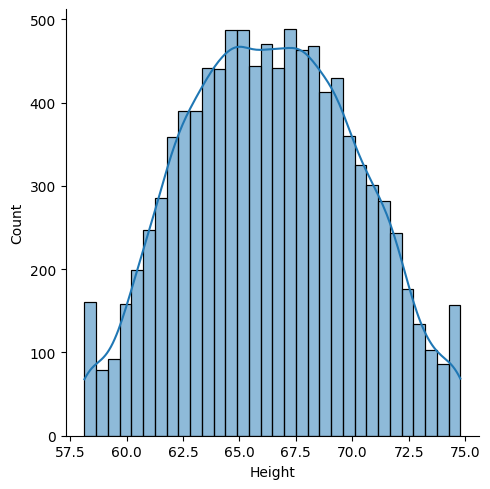

In [29]:
sns.displot(df['Height'],kde=True)

<Axes: xlabel='Height'>

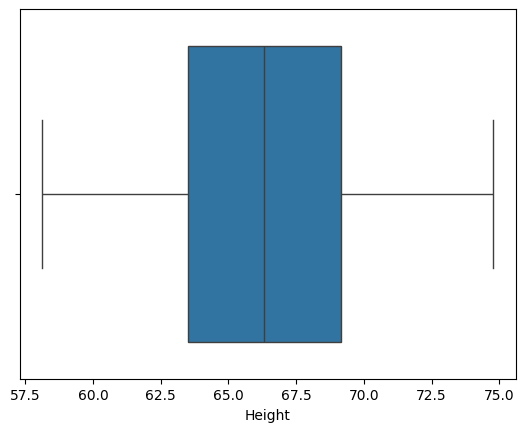

In [31]:
sns.boxplot(x=df['Height'])